# Wav2Vec2 Baseline Model Training

This notebook trains a baseline dementia speech classification model using the Wav2Vec2 architecture.

The model is trained on deterministic audio segments constructed from the DementiaBank dataset. Each recording is segmented into fixed length clips so that the model learns acoustic characteristics associated with dementia rather than artifacts related to recording duration or interview structure.

The training pipeline performs the following steps:

* load dataset manifests generated during dataset construction  
* reconstruct deterministic audio segments from the original recordings  
* convert labels to numeric format for model training  
* preprocess audio using the Wav2Vec2 feature processor  
* apply dynamic batch padding for efficient batching  
* initialize a pretrained Wav2Vec2 encoder with a classification head  
* train the model using class weighted cross entropy loss to mitigate class imbalance  
* evaluate performance on the validation set during training  
* log training metrics and visualize learning curves  
* save the trained model and publish the checkpoint to the HuggingFace Hub

Only training and validation are performed in this notebook. Final model evaluation on the held out test set is conducted separately to preserve a clean experimental protocol.

In [ ]:
!pip install -U transformers datasets accelerate torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 51.5 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


### Mount Google Drive

The project files and dataset manifests are stored in Google Drive.  
This step mounts the drive so the notebook can access the dataset and configuration files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Add Project Directory to Python Path

The project data directory is added to the Python path so that project configuration modules such as `config.py` can be imported during training.

In [ ]:
import sys

PROJECT_DIR = "/content/drive/MyDrive/CS7357_Project/data"

sys.path.append(PROJECT_DIR)

print("Project path added.")

Project path added.


### Wav2Vec2 Baseline Model Training

This notebook trains a baseline dementia speech classification model using the Wav2Vec2 architecture.

The model is trained on deterministic 30 second audio segments constructed from the DementiaBank dataset. Fixed length segmentation reduces shortcut learning from interview structure and recording length artifacts while maintaining reproducibility through deterministic sampling.

Model performance during training is monitored using validation accuracy, precision, recall, and macro F1 score.

In [ ]:
import torch
import torchaudio
import pandas as pd
import numpy as np

from datasets import Dataset

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

### Load Dataset Manifests

Each manifest contains the metadata required to reconstruct the exact audio segment used for training:

* audio file path  
* class label  
* speaker identity  
* deterministic clip start time  
* fixed clip duration  

These fields allow the training pipeline to load the correct 30 second segment from each recording.

In [ ]:
from config import *

train_df = pd.read_csv(TRAIN_MANIFEST, sep="\t")
valid_df = pd.read_csv(VALID_MANIFEST, sep="\t")
test_df = pd.read_csv(TEST_MANIFEST, sep="\t")

print("Train samples:", len(train_df))
print("Valid samples:", len(valid_df))
print("Test samples:", len(test_df))

Train samples: 325
Valid samples: 80
Test samples: 38


### Convert Class Labels to Numeric Format

The dataset labels are converted from string values to numeric identifiers.

nodementia = 0  
dementia = 1

Numeric labels are required for training classification models using PyTorch and HuggingFace Transformers.

In [ ]:
label_map = {
    "nodementia": 0,
    "dementia": 1
}

train_df["label"] = train_df["label"].map(label_map)
valid_df["label"] = valid_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

train_df.head()

,file,label,path,speaker,duration_sec,start_sec,clip_sec,clip_idx
0,alanramsey_10.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,alanramsey,55.0,0.0,30.0,0
1,alanramsey_10.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,alanramsey,55.0,20.0,30.0,1
2,georgerobb_10.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,georgerobb,22.0,0.0,30.0,0
3,andrewsachs_15.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,andrewsachs,90.0,0.0,30.0,0
4,andrewsachs_15.wav,1,/content/drive/My Drive/CS7357_Project/data/de...,andrewsachs,90.0,20.0,30.0,1


### Load Deterministic Audio Segments

Each dataset entry specifies the start time and duration of the audio segment to load from the original recording.

This function loads the correct 30 second segment from each recording using the stored metadata fields:

- start_sec
- clip_sec

Extracting fixed length segments ensures consistent input size and prevents models from learning artifacts related to recording length.

In [ ]:
def load_audio_segment(row):

    path = row["path"]
    start = row["start_sec"]
    clip = row["clip_sec"]

    sr = 16000  # DementiaBank recordings are 16kHz

    frame_offset = int(start * sr)
    num_frames = int(clip * sr)

    waveform, _ = torchaudio.load(
        path,
        frame_offset=frame_offset,
        num_frames=num_frames
    )

    waveform = waveform.squeeze().numpy()

    return waveform

### Convert DataFrames to HuggingFace Dataset Format

The dataset manifests are converted from pandas DataFrames into HuggingFace Dataset objects.

The HuggingFace dataset format enables efficient preprocessing, batching, and integration with the Transformers training pipeline.

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
valid_dataset = Dataset.from_pandas(valid_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset)
print(valid_dataset)
print(test_dataset)

Dataset({
    features: ['file', 'label', 'path', 'speaker', 'duration_sec', 'start_sec', 'clip_sec', 'clip_idx'],
    num_rows: 325
})
Dataset({
    features: ['file', 'label', 'path', 'speaker', 'duration_sec', 'start_sec', 'clip_sec', 'clip_idx'],
    num_rows: 80
})
Dataset({
    features: ['file', 'label', 'path', 'speaker', 'duration_sec', 'start_sec', 'clip_sec', 'clip_idx'],
    num_rows: 38
})


### Hugging Face Log in

In [ ]:
from huggingface_hub import login

login()

### Load Wav2Vec2 Feature Processor

The Wav2Vec2 processor converts raw audio waveforms into normalized input features compatible with the pretrained model.

The baseline experiment uses the standard `facebook/wav2vec2-base` processor.

In [ ]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

### Audio Preprocessing Function

This function performs the preprocessing required before training.

For each dataset sample it:

1. Loads the deterministic 32 second audio segment.
2. Converts the waveform into normalized Wav2Vec2 input features.
3. Assigns the numeric label used during training.

In [ ]:
def preprocess(batch):

    audio = load_audio_segment(batch)

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    batch["input_values"] = inputs.input_values[0]
    batch["labels"] = batch["label"]

    return batch

### Apply Audio Preprocessing

The preprocessing function is applied to all dataset splits to convert raw audio segments into Wav2Vec2 model inputs prior to training.

In [ ]:
train_dataset = train_dataset.map(preprocess)
valid_dataset = valid_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

Map:   0%|          | 0/325 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/38 [00:00<?, ? examples/s]

### Load Wav2Vec2 Classification Model

The baseline classifier uses the pretrained `facebook/wav2vec2-base` model with a sequence classification head for binary dementia detection.

The pretrained encoder provides general speech representations learned from large scale audio corpora.  
A classification head is added and trained on the DementiaBank dataset to perform binary classification.

Output labels:

0 → no dementia  
1 → dementia

The feature encoder is frozen during training so that only the classification layers are updated.  
This stabilizes training and reduces overfitting given the relatively small dataset.

In [ ]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=2
)
model.freeze_feature_encoder()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Compute Class Weights

The training dataset exhibits moderate class imbalance between dementia and non dementia samples.

To reduce bias toward the majority class, class weights are computed using scikit learn's `compute_class_weight` function.  

These weights are later incorporated into the training loss function so that errors on the minority class are penalized more strongly.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_dataset["labels"]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

### Training Configuration

Training parameters define how the model is optimized during fine tuning.

Key settings include:

* learning rate controlling gradient update magnitude  
* batch size determining how many samples are processed per step  
* number of training epochs  
* evaluation frequency during training

Macro F1 score is used as the model selection metric because it balances performance across both dementia classes.  
The best performing checkpoint according to validation macro F1 is automatically restored at the end of training.

In [ ]:
training_args = TrainingArguments(
    output_dir="./baseline_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=22,
    logging_steps=10,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    load_best_model_at_end=True,
    push_to_hub=True,
    hub_model_id="Mrsmetamorphosis/dementia-wav2vec-scientific-baseline"
)

###Custom Trainer with Class Weighted Loss

A custom trainer is implemented to incorporate class weighted cross entropy loss.

This modification ensures that the minority class contributes proportionally more to the loss function, helping mitigate class imbalance during training.

The trainer overrides the default `compute_loss` method from HuggingFace's Trainer class and applies the computed class weights during optimization.

In [ ]:
import torch
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):

  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        class_weights = torch.tensor([1.32, 0.8045]).to(model.device)

        loss_fct = nn.CrossEntropyLoss(weight=class_weights)

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

### Evaluation Metrics

Model performance is evaluated using several standard classification metrics:

* accuracy  
* precision  
* recall  
* macro averaged F1 score

Macro F1 is used as the primary evaluation metric because it treats both classes equally and is robust to class imbalance.

Class specific F1 scores are also reported to assess how well the model detects dementia versus non dementia speech samples.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(pred):
    # Convert model logits to predicted class labels
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    precision_class, recall_class, f1_class, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_nodementia": f1_class[0],
        "f1_dementia": f1_class[1]
    }

### Dynamic Batch Padding

Some recordings are shorter than the full 30 second target window, so waveform lengths may vary across samples.

This custom data collator dynamically pads input waveforms within each batch so they can be stacked into tensors for model training.

Dynamic padding ensures that all inputs within a batch have the same length while avoiding unnecessary padding across the entire dataset, which improves training efficiency.


In [ ]:
def data_collator(features):
    input_features = [{"input_values": f["input_values"]} for f in features]
    label_features = [f["labels"] for f in features]

    batch = processor.pad(
        input_features,
        padding=True,
        return_tensors="pt"
    )

    batch["labels"] = torch.tensor(label_features, dtype=torch.long)
    return batch

### Initialize Trainer

The HuggingFace Trainer manages the full training workflow including:

* forward passes through the model  
* backpropagation and optimizer updates  
* periodic evaluation on the validation dataset  
* logging of training metrics

A custom `WeightedTrainer` class is used so that class weighted cross entropy loss can be applied during optimization to mitigate class imbalance.

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

### Verify Label Distribution Across Dataset Splits

Before training begins, the label distribution of each dataset split is inspected.

This step confirms that both dementia and non dementia classes are present in the training, validation, and test sets and allows verification of class imbalance levels.

In [ ]:
import collections

collections.Counter(train_dataset["labels"])
collections.Counter(valid_dataset["labels"])
collections.Counter(test_dataset["labels"])

Counter({1: 14, 0: 24})

### Train Baseline Model

The model is trained on the training dataset and evaluated on the validation set at the end of each epoch.

During training the optimizer updates only the classification layers while the pretrained encoder remains frozen.

Validation metrics are logged each epoch to monitor convergence and detect potential overfitting.

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,F1 Nodementia,F1 Dementia
1,0.683429,0.683541,0.587500,0.440559,0.469231,0.785714,0.541667,0.153846,0.727273
2,0.606116,0.753298,0.525000,0.366667,0.398333,0.394737,0.479798,0.050000,0.683333
3,0.562696,0.656792,0.625000,0.605003,0.613891,0.622507,0.608586,0.516129,0.693878
4,0.617365,1.083604,0.575000,0.552337,0.542265,0.646953,0.603535,0.653061,0.451613
5,0.669835,0.984652,0.612500,0.594174,0.602798,0.607617,0.597222,0.507937,0.680412
6,0.465901,1.321688,0.612500,0.583823,0.594747,0.611365,0.592172,0.474576,0.693069
7,0.386329,1.347464,0.625000,0.605003,0.613891,0.622507,0.608586,0.516129,0.693878
8,0.206411,1.396604,0.637500,0.604837,0.616198,0.646893,0.614899,0.491228,0.718447
9,0.014212,1.851940,0.575000,0.570707,0.575000,0.570707,0.570707,0.527778,0.613636
10,0.353649,1.934694,0.562500,0.560784,0.563529,0.561288,0.561869,0.533333,0.588235


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1804, training_loss=0.2190173314399026, metrics={'train_runtime': 2665.8059, 'train_samples_per_second': 2.682, 'train_steps_per_second': 0.677, 'total_flos': 1.94736670128e+18, 'train_loss': 0.2190173314399026, 'epoch': 22.0})

In [ ]:
collections.Counter(train_dataset["labels"])

Counter({1: 202, 0: 123})

In [ ]:
print("Train labels:", set(train_dataset["labels"]))
print("Validation labels:", set(valid_dataset["labels"]))
print("Test labels:", set(test_dataset["labels"]))

Train labels: {0, 1}
Validation labels: {0, 1}
Test labels: {0, 1}


In [ ]:
from collections import Counter

print("Train distribution:", Counter(train_dataset["labels"]))
print("Validation distribution:", Counter(valid_dataset["labels"]))
print("Test distribution:", Counter(test_dataset["labels"]))

Train distribution: Counter({1: 202, 0: 123})
Validation distribution: Counter({1: 44, 0: 36})
Test distribution: Counter({0: 24, 1: 14})


### Visualize Training Dynamics

Training logs produced by the HuggingFace Trainer are extracted and converted to a dataframe.

The following curves are plotted across epochs:

* training loss  
* validation loss  
* validation macro F1

These plots provide insight into learning behavior, convergence speed, and potential overfitting.

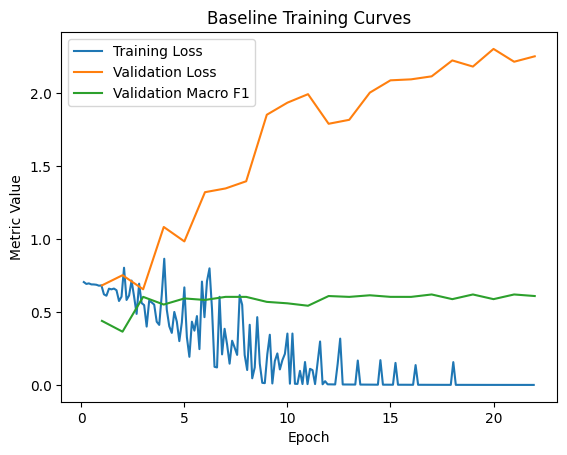

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Extract trainer logs
logs = pd.DataFrame(trainer.state.log_history)

# Keep only rows with epoch values
logs = logs[logs["epoch"].notna()]

# Separate training and validation metrics
train_loss = logs[logs["loss"].notna()][["epoch", "loss"]]
val_loss = logs[logs["eval_loss"].notna()][["epoch", "eval_loss"]]
val_f1 = logs[logs["eval_f1_macro"].notna()][["epoch", "eval_f1_macro"]]

plt.figure()

plt.plot(train_loss["epoch"], train_loss["loss"], label="Training Loss")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Validation Loss")
plt.plot(val_f1["epoch"], val_f1["eval_f1_macro"], label="Validation Macro F1")

plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Baseline Training Curves")
plt.legend()
plt.show()

### Save Training Curve Figure

The training curve visualization is saved as a high resolution PNG for inclusion in reports and analysis.

In [ ]:
plt.savefig("baseline_training_curves.png", dpi=300)

<Figure size 640x480 with 0 Axes>

### Publish Trained Model

The trained baseline model and processor are uploaded to the HuggingFace Hub.

This allows the model to be easily shared, versioned, and reproduced by loading the checkpoint directly from the repository.

In [ ]:
trainer.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...e_model/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

  ...e_model/model.safetensors:  11%|#         | 39.9MB /  378MB            

CommitInfo(commit_url='https://huggingface.co/Mrsmetamorphosis/dementia-wav2vec-scientific-baseline/commit/75baaf13b5e38bb1fc0d0071b70592aeb0b1f590', commit_message='End of training', commit_description='', oid='75baaf13b5e38bb1fc0d0071b70592aeb0b1f590', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Mrsmetamorphosis/dementia-wav2vec-scientific-baseline', endpoint='https://huggingface.co', repo_type='model', repo_id='Mrsmetamorphosis/dementia-wav2vec-scientific-baseline'), pr_revision=None, pr_num=None)

In [ ]:
processor.push_to_hub("Mrsmetamorphosis/dementia-wav2vec-scientific-baseline")

README.md: 0.00B [00:00, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Mrsmetamorphosis/dementia-wav2vec-scientific-baseline/commit/75baaf13b5e38bb1fc0d0071b70592aeb0b1f590', commit_message='Upload processor', commit_description='', oid='75baaf13b5e38bb1fc0d0071b70592aeb0b1f590', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Mrsmetamorphosis/dementia-wav2vec-scientific-baseline', endpoint='https://huggingface.co', repo_type='model', repo_id='Mrsmetamorphosis/dementia-wav2vec-scientific-baseline'), pr_revision=None, pr_num=None)